## 0. Setup

### What?
Import libraries and define constants: API base URL, series codes, and target date range.

### Why?
Centralising all series IDs here means a future change (e.g. INE publishes a Base 2020 IPI) only requires editing this one cell.

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

NOTEBOOK_DIR = Path().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent
DATA_INPUTS   = REPO_ROOT / 'data' / 'inputs'
DATA_FEATURES = REPO_ROOT / 'data' / 'features'
DATA_OUTPUTS  = REPO_ROOT / 'data' / 'outputs'
FIGURES = REPO_ROOT / 'reports' / 'figures'

INE_API = "https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/{series_id}?nult={nult}"

# Target period: align with CORES biodiesel data
DATE_START = '2023-01'
DATE_END   = '2025-12'

# Verified series IDs (confirmed against INE API June 2026)
SERIES = {
    'IPI_original':     'IPI13491',   # Total Nacional. Total industria. Índice.
    'IPI_ajustado':     'IPI15360',   # Total Nacional. Índice. Ajustado estacionalidad.
    'IPC_var_anual':    'IPC251856',  # Nacional. Índice general. Variación anual.
    'Tasa_paro':        'EPA423474',  # Total Nacional. Tasa de paro. Ambos sexos. Total.
}

print(f"Repo root:  {REPO_ROOT}")
print(f"Target period: {DATE_START} → {DATE_END}")

Repo root:  C:\Users\sacha\OneDrive\IE\Master in Business Analytics and Data Science\Term 3\Capstone Project\repsol-capstone
Target period: 2023-01 → 2025-12


## 1. INE API Helper Functions

### What?
Build two functions:
- `fetch_ine_series()` — fetches one series and returns a tidy DataFrame with `Fecha` and a value column.
- `quarterly_to_monthly()` — expands quarterly EPA observations to monthly (forward-fill within each quarter).

### Why?
A reusable function avoids duplicating request/parsing logic and makes it easy to add new series in future sprints. The quarterly expansion is necessary because our model targets and most features are monthly — mixing granularities without alignment would leak future information.

In [2]:
def fetch_ine_series(series_id: str, col_name: str, nult: int = 50) -> pd.DataFrame:
    """
    Fetch a single INE Tempus3 series and return a tidy DataFrame.

    Returns columns: Fecha (YYYY-MM string), <col_name> (float).
    Monthly series  : Fecha = YYYY-MM derived from FK_Periodo (1-12).
    Quarterly series: Fecha = first month of the quarter, derived from the
                      Fecha timestamp (end-of-quarter date).

    INE API real field names: Anyo (year), FK_Periodo (period code), Valor.
    EPA quarterly codes: 19=Q4-prev-year, 20=Q1, 21=Q2, 22=Q3.  Because Q4
    of year N is labelled Anyo=N+1 in the API, we always use the ms timestamp
    for quarterly series to extract the correct date.
    """
    from datetime import datetime

    url = INE_API.format(series_id=series_id, nult=nult)
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    payload = resp.json()

    records = []
    data_list = payload.get('Data', payload) if isinstance(payload, dict) else payload

    for obs in data_list:
        anyo     = obs.get('Anyo')
        periodo  = obs.get('FK_Periodo')
        valor    = obs.get('Valor')
        fecha_ms = obs.get('Fecha')

        if anyo is None or periodo is None or valor is None:
            continue

        if periodo <= 12:
            # Monthly series: FK_Periodo is the month number (1-12)
            month = periodo
            year  = anyo
        else:
            # Quarterly series: use the ms timestamp to get end-of-quarter month,
            # then map to the first month of that quarter.
            if fecha_ms is None:
                continue
            dt = datetime.utcfromtimestamp(fecha_ms / 1000)
            end_month = dt.month
            year  = dt.year
            month = {3: 1, 6: 4, 9: 7, 12: 10}.get(end_month)
            if month is None:
                continue  # unexpected timestamp month

        records.append({'Fecha': f'{int(year)}-{int(month):02d}', col_name: float(valor)})

    if not records:
        raise ValueError(f"No data parsed for series {series_id} — check the API response.")

    df = pd.DataFrame(records).drop_duplicates('Fecha').sort_values('Fecha').reset_index(drop=True)
    print(f"  {series_id}: {len(df)} obs | {df['Fecha'].min()} → {df['Fecha'].max()}")
    return df


def quarterly_to_monthly(df: pd.DataFrame, col_name: str) -> pd.DataFrame:
    """
    Expand quarterly Fecha values (first month of quarter) to cover all 3 months
    of the FOLLOWING quarter, using forward-fill.

    EPA quarterly figures are published about a month after the quarter ends,
    so a quarter's confirmed value is only actually known starting the next
    quarter. Shifting the quarterly index forward by one quarter (3 months)
    before forward-filling means each month sees the prior quarter's published
    value, never its own (not-yet-published) quarter's value. Without this
    shift, the first 1-3 months of every quarter would leak a figure that
    would not exist yet in real-time forecasting.
    """
    df = df.copy()
    df['Fecha_dt'] = pd.to_datetime(df['Fecha']) + pd.DateOffset(months=3)

    monthly_idx = pd.date_range(
        df['Fecha_dt'].min(),
        df['Fecha_dt'].max() + pd.DateOffset(months=2),
        freq='MS'
    )
    df_monthly = pd.DataFrame({'Fecha_dt': monthly_idx})
    df_monthly = df_monthly.merge(df[['Fecha_dt', col_name]], on='Fecha_dt', how='left')
    df_monthly[col_name] = df_monthly[col_name].ffill()
    df_monthly['Fecha'] = df_monthly['Fecha_dt'].dt.strftime('%Y-%m')
    return df_monthly[['Fecha', col_name]].dropna()


print("Helper functions defined.")

Helper functions defined.


## 2. Download INE Series

### What?
Fetch the four series using the helper function. Request `nult=60` (last 60 observations) to ensure we have more than enough history covering our 2023-2025 window — we filter to the exact range in the merge step.

### Why?
Requesting slightly more history than needed allows us to compute lag features later without losing observations at the start of the series.

In [3]:
print("Downloading INE series...")
print()

df_ipi    = fetch_ine_series(SERIES['IPI_original'],  'IPI_original',  nult=60)
df_ipi_sa = fetch_ine_series(SERIES['IPI_ajustado'],  'IPI_ajustado',  nult=60)
df_ipc    = fetch_ine_series(SERIES['IPC_var_anual'], 'IPC_var_anual', nult=60)
df_epa    = fetch_ine_series(SERIES['Tasa_paro'],     'Tasa_paro',     nult=24)  # 24 quarters ≈ 6 years

print()
print("IPI sample:")
print(df_ipi.tail(6).to_string(index=False))
print()
print("EPA quarterly sample (before interpolation):")
print(df_epa.tail(8).to_string(index=False))

  IPI13491: 60 obs | 2021-05 → 2026-04


  IPI15360: 60 obs | 2021-05 → 2026-04
  IPC251856: 60 obs | 2021-01 → 2025-12


  EPA423474: 24 obs | 2020-01 → 2025-10

IPI sample:
  Fecha  IPI_original
2025-11       106.113
2025-12        95.598
2026-01        97.162
2026-02       100.351
2026-03       110.524
2026-04       102.593

EPA quarterly sample (before interpolation):
  Fecha  Tasa_paro
2024-01      11.27
2024-04      11.21
2024-07      10.61
2024-10      11.36
2025-01      10.29
2025-04      10.45
2025-07       9.93
2025-10      10.83


C:\Users\sacha\AppData\Local\Temp\ipykernel_38176\221205748.py:43: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt = datetime.utcfromtimestamp(fecha_ms / 1000)


## 3. Expand EPA from Quarterly to Monthly

### What?
Apply forward-fill to extend each quarterly EPA value across the three months of the FOLLOWING quarter (not its own quarter).

### Why?
The EPA is published roughly a month after the quarter it describes ends, so a quarter's figure is not actually known until the next quarter has started. Assigning a quarter's value to its own January/February/March would leak a not-yet-published number into those months. Shifting the value forward by one quarter before forward-filling means each month only ever sees the most recently *published* EPA figure — the standard, causally correct approach for mixed-frequency panel data.

In [4]:
df_epa_monthly = quarterly_to_monthly(df_epa, 'Tasa_paro')

print("EPA monthly (forward-filled):")
print(df_epa_monthly[df_epa_monthly['Fecha'] >= '2023-01'].tail(12).to_string(index=False))

EPA monthly (forward-filled):
  Fecha  Tasa_paro
2025-04      10.29
2025-05      10.29
2025-06      10.29
2025-07      10.45
2025-08      10.45
2025-09      10.45
2025-10       9.93
2025-11       9.93
2025-12       9.93
2026-01      10.83
2026-02      10.83
2026-03      10.83


## 4. Build the Macro Feature Matrix

### What?
Left-join all four series onto a complete monthly spine (Jan 2023 → Dec 2025), then filter to the target window.

### Why?
Using a spine (master date index) ensures we never accidentally drop months due to mismatched series start dates. Any gap left by a missing series observation is flagged as NaN rather than silently dropped.

In [5]:
# Full monthly spine for our target window
months = pd.date_range(DATE_START, DATE_END, freq='MS').strftime('%Y-%m').tolist()
df_macro = pd.DataFrame({'Fecha': months})

# Merge each series
for df_series in [df_ipi, df_ipi_sa, df_ipc, df_epa_monthly]:
    df_macro = df_macro.merge(df_series, on='Fecha', how='left')

print("=" * 60)
print("MACRO FEATURE MATRIX")
print("=" * 60)
print(f"Shape: {df_macro.shape}")
print(f"Period: {df_macro['Fecha'].iloc[0]} → {df_macro['Fecha'].iloc[-1]}")
print()
print("Null count per column:")
print(df_macro.isnull().sum())
print()
print("Descriptive stats:")
print(df_macro.describe().round(2))
print()
print("First 6 rows:")
print(df_macro.head(6).to_string(index=False))

MACRO FEATURE MATRIX
Shape: (36, 5)
Period: 2023-01 → 2025-12

Null count per column:
Fecha            0
IPI_original     0
IPI_ajustado     0
IPC_var_anual    0
Tasa_paro        0
dtype: int64

Descriptive stats:
       IPI_original  IPI_ajustado  IPC_var_anual  Tasa_paro
count         36.00         36.00          36.00      36.00
mean         101.58        101.43           3.00      11.35
std            8.65          1.21           0.92       0.93
min           78.45         99.16           1.50       9.93
25%           99.57        100.57           2.38      10.57
50%          103.42        101.30           2.95      11.32
75%          107.48        102.24           3.30      11.82
max          113.73        104.43           6.00      13.38

First 6 rows:
  Fecha  IPI_original  IPI_ajustado  IPC_var_anual  Tasa_paro
2023-01        97.874       101.664            5.9      13.38
2023-02        99.947       100.678            6.0      13.38
2023-03       113.733       102.479          

## 5. Handle Any Missing Values

### What?
Check for NaN values in the feature matrix and apply linear interpolation for isolated gaps.

### Why?
A handful of missing values at series boundaries (e.g. a 1-month lag in publication) can be safely interpolated without introducing bias. If more than 2 consecutive months are missing for any variable, we flag it for manual inspection rather than silently filling.

In [6]:
FILL_THRESHOLD = 2  # flag if more than this many consecutive NaNs

feature_cols = ['IPI_original', 'IPI_ajustado', 'IPC_var_anual', 'Tasa_paro']

for col in feature_cols:
    n_null = df_macro[col].isnull().sum()
    if n_null == 0:
        print(f"  {col}: no missing values")
        continue

    # Check for consecutive gaps
    max_consec = df_macro[col].isnull().astype(int).groupby(
        df_macro[col].notnull().astype(int).cumsum()
    ).sum().max()

    if max_consec > FILL_THRESHOLD:
        print(f"  WARNING {col}: {n_null} nulls, max consecutive gap = {max_consec} — review manually")
    else:
        df_macro[col] = df_macro[col].interpolate(method='linear')
        print(f"  {col}: {n_null} nulls filled via linear interpolation (max gap = {max_consec})")

print()
print(f"Final null count: {df_macro.isnull().sum().sum()}")

  IPI_original: no missing values
  IPI_ajustado: no missing values
  IPC_var_anual: no missing values
  Tasa_paro: no missing values

Final null count: 0


## 6. Visualise the Macro Variables

### What?
Plot each macro variable over the 2023–2025 period.

### Why?
Visual inspection catches API parsing errors (unexpected spikes, flat lines, wrong scale) that descriptive statistics miss. This is the final quality gate before saving.

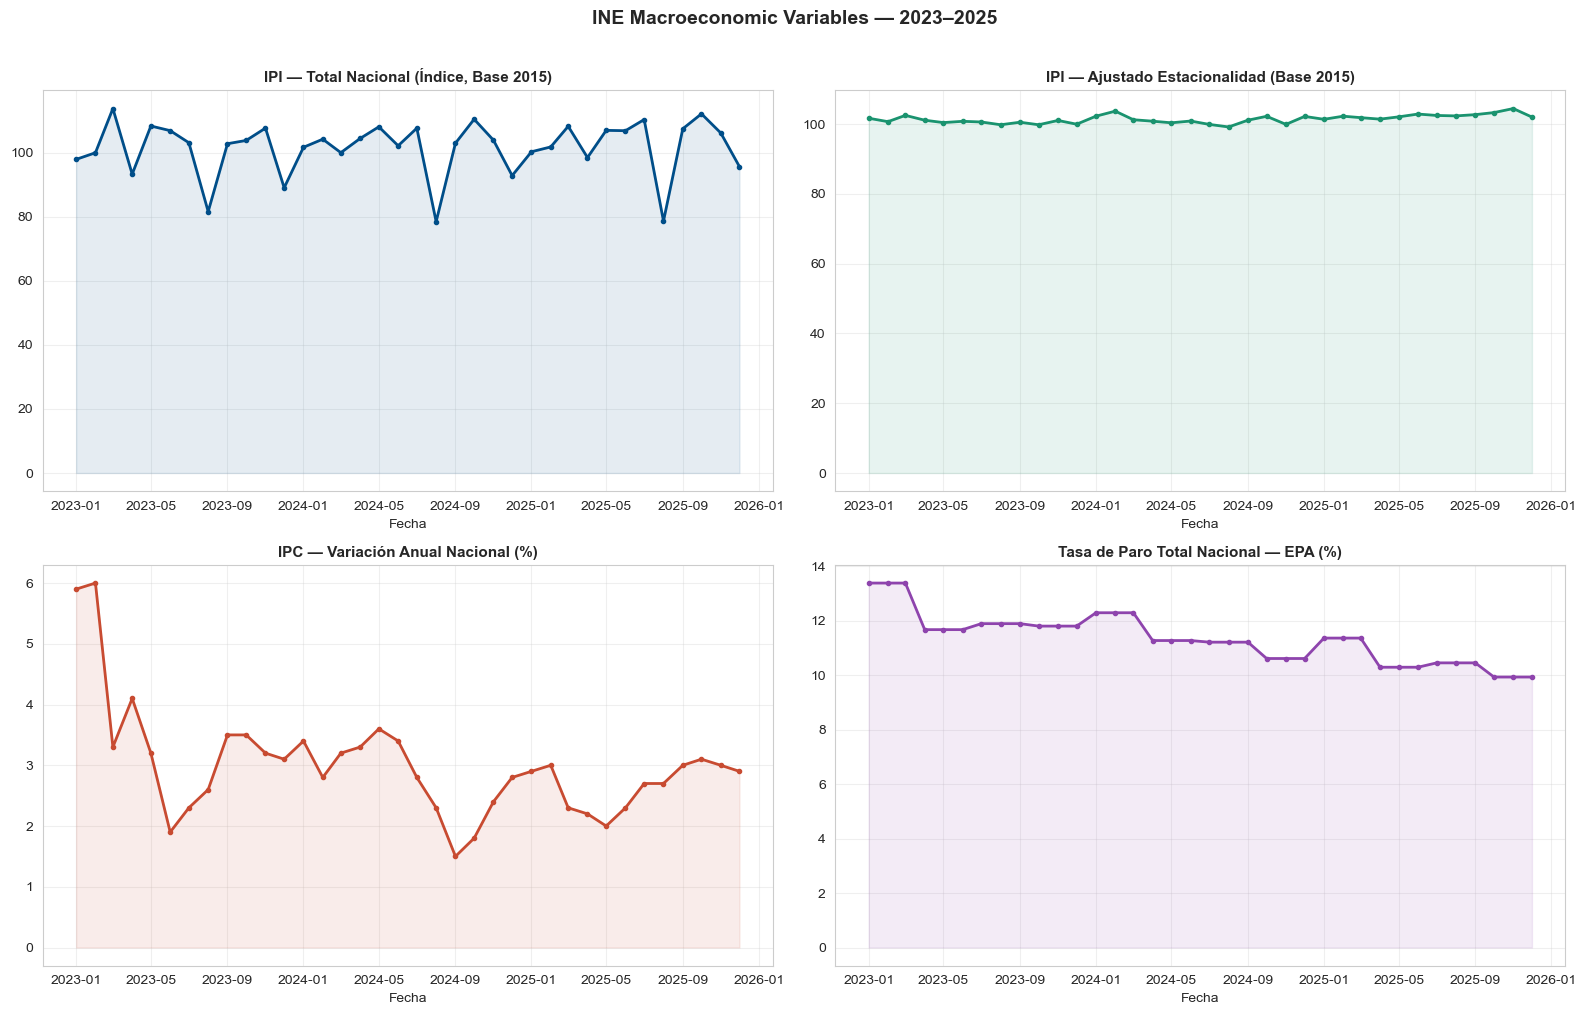

Figure saved: 07_macro_variables.png


In [7]:
df_macro['Fecha_dt'] = pd.to_datetime(df_macro['Fecha'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

plot_config = [
    ('IPI_original',  'IPI — Total Nacional (Índice, Base 2015)',       '#004E89'),
    ('IPI_ajustado',  'IPI — Ajustado Estacionalidad (Base 2015)',       '#1A936F'),
    ('IPC_var_anual', 'IPC — Variación Anual Nacional (%)',              '#C84B31'),
    ('Tasa_paro',     'Tasa de Paro Total Nacional — EPA (%)',           '#8E44AD'),
]

for ax, (col, title, color) in zip(axes, plot_config):
    ax.plot(df_macro['Fecha_dt'], df_macro[col], color=color, linewidth=2, marker='o', markersize=3)
    ax.fill_between(df_macro['Fecha_dt'], df_macro[col], alpha=0.1, color=color)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.grid(True, alpha=0.3)

fig.suptitle('INE Macroeconomic Variables — 2023–2025', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '07_macro_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 07_macro_variables.png")

## 7. Correlate with Biodiesel Consumption

### What?
Merge macro features with the national biodiesel series and compute the Pearson correlation matrix.

### Why?
Before feature engineering, a simple correlation check confirms which macro variables have a meaningful linear relationship with biodiesel demand. This guides which variables deserve lag features in the next notebook.

Pearson correlations with Consumo_Tm (national biodiesel demand):
IPI_ajustado     0.563
IPI_original     0.073
IPC_var_anual   -0.369
Tasa_paro       -0.829
Name: Consumo_Tm, dtype: float64


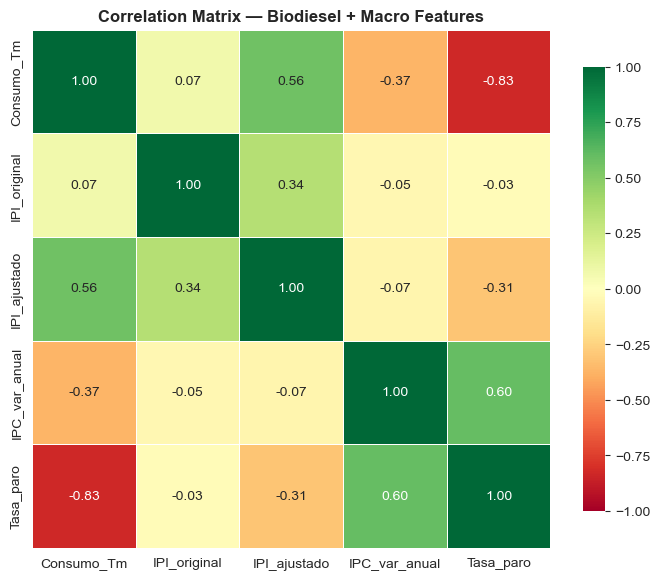

Figure saved: 08_correlacion_macro.png


In [8]:
df_targets = pd.read_csv(DATA_INPUTS   / 'consumo_biodiesel_targets.csv')
df_nacional = df_targets[df_targets['Target'] == 'Nacional'][['Fecha', 'Consumo_Tm']].copy()

df_corr = df_nacional.merge(df_macro[['Fecha'] + feature_cols], on='Fecha', how='left')

corr_matrix = df_corr[['Consumo_Tm'] + feature_cols].corr()

print("Pearson correlations with Consumo_Tm (national biodiesel demand):")
print(corr_matrix['Consumo_Tm'].drop('Consumo_Tm').sort_values(ascending=False).round(3))

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, square=True, ax=ax,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Biodiesel + Macro Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '08_correlacion_macro.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 08_correlacion_macro.png")

## 8. DGT — Vehicle Fleet Data (Manual Download Required)

### What?
The DGT (Dirección General de Tráfico) publishes annual fleet statistics and monthly vehicle registration data. These require manual download.

### Why?
The DGT does not provide a public JSON API. The data is published as PDF/Excel files. Instructions below.

---

**Data to download:**

| Dataset | Where to find | Variable to extract |
|---------|--------------|--------------------|
| Parque de vehículos (annual) | [DGT Estadísticas](https://www.dgt.es/inicio/estadisticas-e-informes/estadisticas-de-vehiculos/) | Total camiones + furgonetas por año |
| Matriculaciones mensuales | [DGT Permisos de circulación](https://www.dgt.es/inicio/estadisticas-e-informes/estadisticas-de-matriculaciones/) | Matriculaciones mensuales vehículos industriales |

**Once downloaded:**
- Save to `data/raw/dgt_parque_vehiculos.xlsx`
- Save to `data/raw/dgt_matriculaciones.xlsx`
- Run the cell below to process them

---

In [9]:
# DGT processing placeholder — uncomment once files are downloaded
# -----------------------------------------------------------------
# from pathlib import Path
#
# dgt_parque_path = REPO_ROOT / 'data' / 'raw' / 'dgt_parque_vehiculos.xlsx'
# dgt_matr_path   = REPO_ROOT / 'data' / 'raw' / 'dgt_matriculaciones.xlsx'
#
# if dgt_parque_path.exists():
#     df_parque = pd.read_excel(dgt_parque_path)
#     print(df_parque.head())
# else:
#     print("DGT file not found — download manually (see instructions above)")

print("DGT placeholder cell — run after downloading files from DGT website.")

DGT placeholder cell — run after downloading files from DGT website.


## 9. Save Macro Feature Matrix

### What?
Save the final feature matrix to `data/processed/macro_features.csv`.

### Why?
The next notebook (`05_feature_engineering.ipynb`) reads this file to build lag features, rolling averages, and seasonal indicators. Saving it here decouples the download step from engineering — useful if INE changes a series and you need to re-run only this notebook.

In [10]:
out_path = DATA_INPUTS   / 'macro_indicadores_ine.csv'
df_macro.drop(columns=['Fecha_dt'], errors='ignore').to_csv(out_path, index=False, encoding='utf-8')

print(f"Saved: {out_path.name}")
print(f"Shape: {df_macro.shape}")
print(f"Columns: {df_macro.drop(columns=['Fecha_dt'], errors='ignore').columns.tolist()}")
print()

# Verification read
verify = pd.read_csv(out_path)
print("Verification — first 3 rows:")
print(verify.head(3).to_string(index=False))
print("\nNull count in saved file:")
print(verify.isnull().sum())

Saved: macro_indicadores_ine.csv
Shape: (36, 6)
Columns: ['Fecha', 'IPI_original', 'IPI_ajustado', 'IPC_var_anual', 'Tasa_paro']

Verification — first 3 rows:
  Fecha  IPI_original  IPI_ajustado  IPC_var_anual  Tasa_paro
2023-01        97.874       101.664            5.9      13.38
2023-02        99.947       100.678            6.0      13.38
2023-03       113.733       102.479            3.3      13.38

Null count in saved file:
Fecha            0
IPI_original     0
IPI_ajustado     0
IPC_var_anual    0
Tasa_paro        0
dtype: int64


## 10. Summary

### Sprint 2 — External Data: DONE ✅

| Variable | Series | Coverage | Notes |
|----------|--------|----------|-------|
| IPI original | IPI13491 | Monthly 2023–2025 | Industrial production index, Base 2015 |
| IPI ajustado | IPI15360 | Monthly 2023–2025 | Seasonally adjusted |
| IPC variación anual | IPC251856 | Monthly 2023–2025 | National CPI annual change |
| Tasa de paro | EPA423474 | Quarterly → Monthly | Forward-filled within quarter |
| DGT fleet | — | Manual download | Placeholder ready |

**Output file:** `data/processed/macro_features.csv` — 36 rows × 5 columns

### Next step → `05_feature_engineering.ipynb`
Combine CORES targets + macro features → build lag variables, rolling statistics, seasonal dummies, and trend features. Output: `data/processed/model_dataset.csv`.